# **Analisis Prediksi Data Penjualan Toko Buku Menggunakan Model Machine Learning**

**1. IMPORT LIBRARY**

In [2]:
!pip install lightgbm catboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import warnings
warnings.filterwarnings('ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.8 MB/s eta 0:00:00


**2. LOAD DATASET**

In [3]:
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
df = pd.read_csv('/content/Data Penjualan Toko Buku.csv')
print("Jumlah data:", len(df))
df.head(4000)

Saving Data Penjualan Toko Buku.csv to Data Penjualan Toko Buku.csv
Jumlah data: 3240


,id_transaksi,jenis_item,jumlah,tanggal pembelian,nama_customer,total
0,133889.0,Alat Tulis,1,1/1/2010,Stacy Campos,120000.0
1,133889.0,Buku Sejarah,1,1/1/2010,Stacy Campos,150000.0
2,133889.0,Buku Anak-Anak,2,1/1/2010,Stacy Campos,400000.0
3,133889.0,Majalah Fashion,1,1/1/2010,Stacy Campos,130000.0
4,133889.0,Majalah Berita,2,1/1/2010,Stacy Campos,600000.0
...,...,...,...,...,...,...
3235,NaN,NaN,2,4/30/2024,NaN,240000.0
3236,NaN,NaN,6,4/30/2024,NaN,1800000.0
3237,NaN,NaN,1,4/30/2024,NaN,90000.0
3238,NaN,NaN,9,4/30/2024,NaN,180000.0


**3. DATA UNDERSTANDING**

In [4]:
print("\n")
print("="*60)
print("INFORMASI DATASET")
print("="*60)
print(df.info())

print("\n")
print("="*60)
print("STATISTIK DESKRIPTIF")
print("="*60)
print(df.describe())

print("\n")
print("="*60)
print("MISSING VALUE")
print("="*60)
print(df.isnull().sum())

print("\n")
print("="*60)
print("JUMLAH DUPLIKAT")
print("="*60)
print(df.duplicated().sum())



INFORMASI DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3240 entries, 0 to 3239
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_transaksi       2469 non-null   float64
 1   jenis_item         2469 non-null   object 
 2   jumlah             3240 non-null   int64  
 3   tanggal pembelian  3237 non-null   object 
 4   nama_customer      2469 non-null   object 
 5   total              3238 non-null   float64
dtypes: float64(2), int64(1), object(3)
memory usage: 152.0+ KB
None


STATISTIK DESKRIPTIF
        id_transaksi       jumlah         total
count    2469.000000  3240.000000  3.238000e+03
mean   134091.579587     4.961420  2.284234e+06
std       116.506946     2.602762  2.780856e+06
min    133889.000000     1.000000  2.000000e+04
25%    133992.000000     3.000000  2.250000e+05
50%    134090.000000     5.000000  1.170000e+06
75%    134192.000000     7.000000  3.247500e+06
max    134294.

**4. PREPROCESSING**

In [5]:
# Rename kolom
df.columns = [
    'id_transaksi',
    'jenis_item',
    'jumlah',
    'tanggal_pembelian',
    'nama_customer',
    'total'
]

# Hapus missing value
df = df.dropna()

# Hapus data duplikat
df = df.drop_duplicates()

# Konversi tanggal
df['tanggal_pembelian'] = pd.to_datetime(
    df['tanggal_pembelian'],
    errors='coerce'
)

# Hapus jika masih ada tanggal invalid
df = df.dropna()

print("Data setelah dibersihkan:", len(df))
df[['id_transaksi', 'jenis_item', 'jumlah', 'tanggal_pembelian', 'nama_customer', 'total']].head(4000)

Data setelah dibersihkan: 2464


,id_transaksi,jenis_item,jumlah,tanggal_pembelian,nama_customer,total
0,133889.0,Alat Tulis,1,2010-01-01,Stacy Campos,120000.0
1,133889.0,Buku Sejarah,1,2010-01-01,Stacy Campos,150000.0
2,133889.0,Buku Anak-Anak,2,2010-01-01,Stacy Campos,400000.0
3,133889.0,Majalah Fashion,1,2010-01-01,Stacy Campos,130000.0
4,133889.0,Majalah Berita,2,2010-01-01,Stacy Campos,600000.0
...,...,...,...,...,...,...
2464,134294.0,Alat Tulis,3,2024-04-30,Richard Jones,180000.0
2465,134294.0,Buku Sejarah,4,2024-04-30,Richard Jones,2400000.0
2466,134294.0,Buku Anak-Anak,2,2024-04-30,Richard Jones,80000.0
2467,134294.0,Majalah Fashion,9,2024-04-30,Richard Jones,1620000.0


**5. FEATURE ENGINEERING**

In [6]:
# Fitur waktu
df['tahun'] = df['tanggal_pembelian'].dt.year
df['bulan'] = df['tanggal_pembelian'].dt.month
df['minggu'] = df['tanggal_pembelian'].dt.isocalendar().week.astype(int)
df['hari'] = df['tanggal_pembelian'].dt.day

# AGREGASI PENJUALAN MINGGUAN
weekly_sales = df.groupby(
    ['tahun', 'bulan', 'minggu', 'jenis_item']
).agg({
    'total':'sum',
    'jumlah':'sum'
}).reset_index()

weekly_sales.rename(
    columns={
        'total':'total_penjualan',
        'jumlah':'total_item'
    },
    inplace=True
)

print("\n")
print("="*60)
print("DATA PENJUALAN MINGGUAN")
print("="*60)
print(weekly_sales.head())

# ENCODING
le = LabelEncoder()

weekly_sales['jenis_item_encoded'] = le.fit_transform(
    weekly_sales['jenis_item']
)

# SORTING TIME SERIES
weekly_sales = weekly_sales.sort_values(
    by=['jenis_item_encoded', 'tahun', 'minggu']
)

# LAG FEATURES
weekly_sales['lag_1'] = weekly_sales.groupby(
    'jenis_item_encoded'
)['total_penjualan'].shift(1)

weekly_sales['lag_2'] = weekly_sales.groupby(
    'jenis_item_encoded'
)['total_penjualan'].shift(2)

weekly_sales['lag_3'] = weekly_sales.groupby(
    'jenis_item_encoded'
)['total_penjualan'].shift(3)

weekly_sales['lag_4'] = weekly_sales.groupby(
    'jenis_item_encoded'
)['total_penjualan'].shift(4)

# ROLLING FEATURES
weekly_sales['rolling_mean_4'] = weekly_sales.groupby(
    'jenis_item_encoded'
)['total_penjualan'].transform(
    lambda x: x.shift(1).rolling(window=4).mean()
)

weekly_sales['rolling_std_4'] = weekly_sales.groupby(
    'jenis_item_encoded'
)['total_penjualan'].transform(
    lambda x: x.shift(1).rolling(window=4).std()
)

# DROP NA
weekly_sales = weekly_sales.dropna()

print("\n")
print("="*60)
print("JUMLAH DATA SETELAH FEATURE ENGINEERING")
print("="*60)
print(weekly_sales.shape)



DATA PENJUALAN MINGGUAN
   tahun  bulan  minggu      jenis_item  total_penjualan  total_item
0   2010      1      53      Alat Tulis         120000.0           1
1   2010      1      53  Buku Anak-Anak         400000.0           2
2   2010      1      53      Buku Fiksi        1170000.0           3
3   2010      1      53    Buku Sejarah         150000.0           1
4   2010      1      53  Majalah Berita         600000.0           2


JUMLAH DATA SETELAH FEATURE ENGINEERING
(581, 13)


**6. EDA**

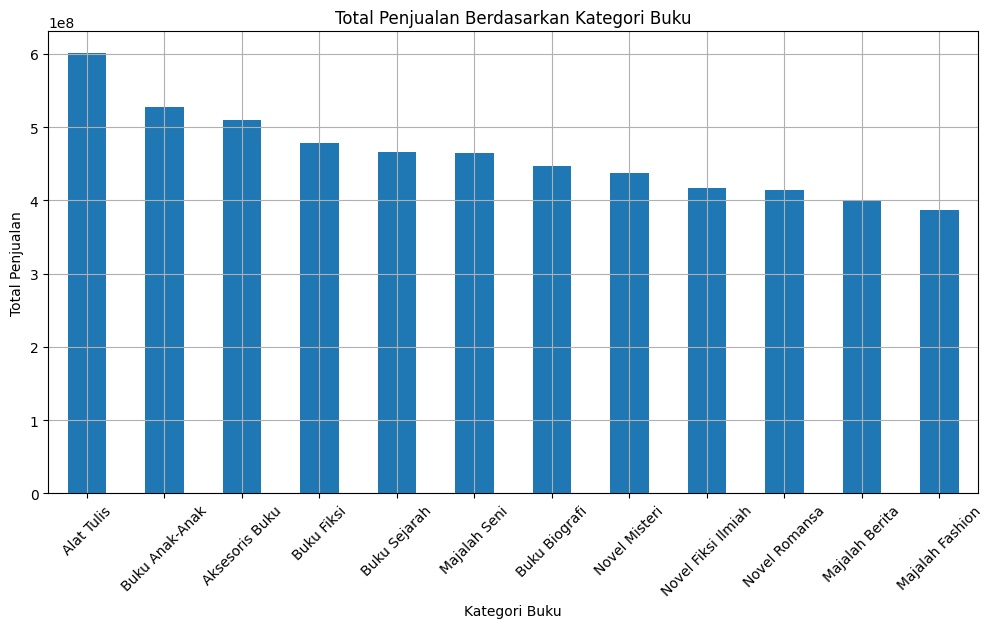

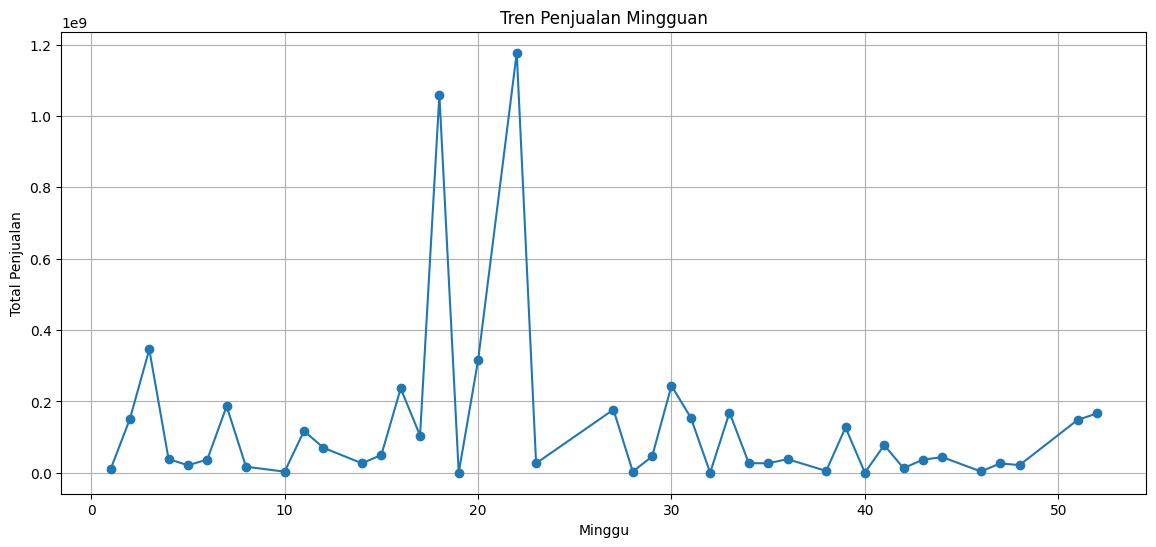

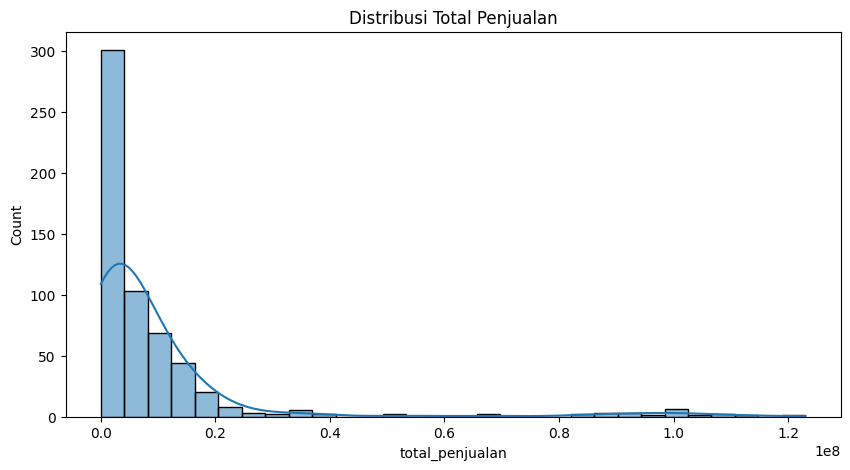

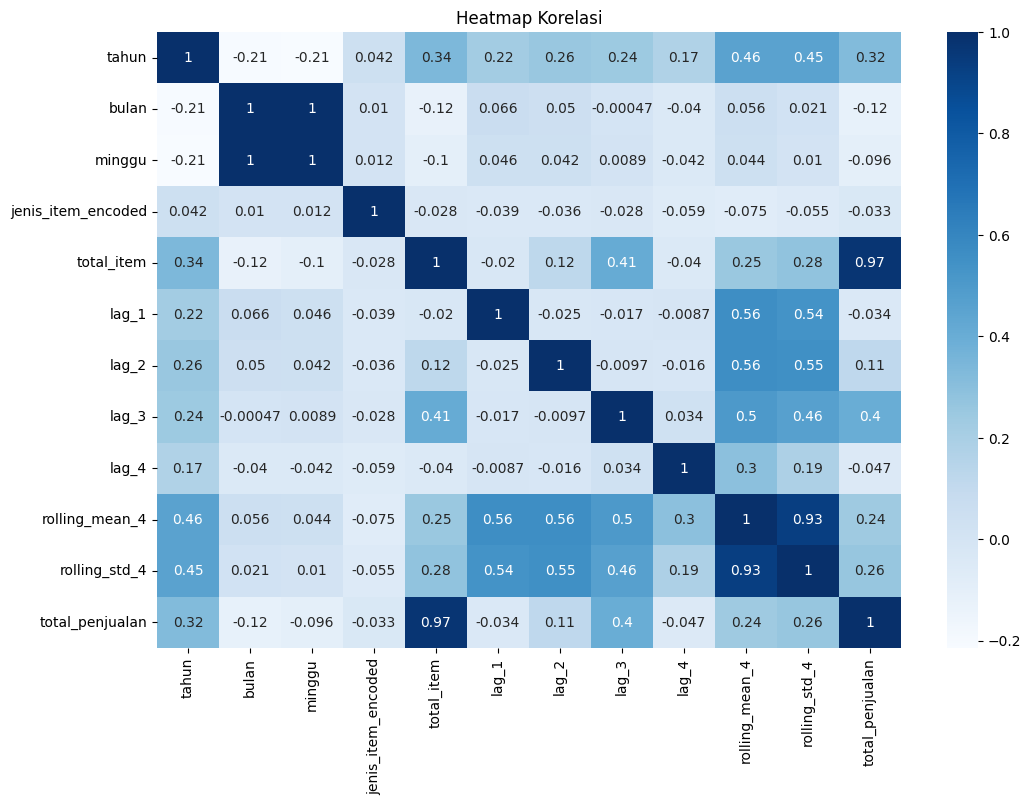

In [7]:
# TOTAL PENJUALAN KATEGORI
plt.figure(figsize=(12,6))

top_category = weekly_sales.groupby(
    'jenis_item'
)['total_penjualan'].sum().sort_values(
    ascending=False
)

top_category.plot(kind='bar')

plt.title('Total Penjualan Berdasarkan Kategori Buku')
plt.xlabel('Kategori Buku')
plt.ylabel('Total Penjualan')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

# TREN PENJUALAN MINGGUAN
plt.figure(figsize=(14,6))

weekly_total = weekly_sales.groupby(
    'minggu'
)['total_penjualan'].sum()

weekly_total.plot(marker='o')

plt.title('Tren Penjualan Mingguan')
plt.xlabel('Minggu')
plt.ylabel('Total Penjualan')
plt.grid(True)
plt.show()

# DISTRIBUSI TARGET
plt.figure(figsize=(10,5))

sns.histplot(
    weekly_sales['total_penjualan'],
    bins=30,
    kde=True
)

plt.title('Distribusi Total Penjualan')
plt.show()

# HEATMAP KORELASI
plt.figure(figsize=(12,8))

corr = weekly_sales[
    [
        'tahun',
        'bulan',
        'minggu',
        'jenis_item_encoded',
        'total_item',
        'lag_1',
        'lag_2',
        'lag_3',
        'lag_4',
        'rolling_mean_4',
        'rolling_std_4',
        'total_penjualan'
    ]
].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='Blues'
)

plt.title('Heatmap Korelasi')
plt.show()

**7. SPLIT DATA**

In [8]:
X = weekly_sales[
    [
        'tahun',
        'bulan',
        'minggu',
        'jenis_item_encoded',
        'total_item',
        'lag_1',
        'lag_2',
        'lag_3',
        'lag_4',
        'rolling_mean_4',
        'rolling_std_4'
    ]
]

y = weekly_sales['total_penjualan']

# =========================================================
# SPLIT TANPA SHUFFLE (TIME SERIES)
# =========================================================
split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("\n")
print("="*60)
print("UKURAN DATA TRAIN & TEST")
print("="*60)
print("X Train :", X_train.shape)
print("X Test  :", X_test.shape)



UKURAN DATA TRAIN & TEST
X Train : (464, 11)
X Test  : (117, 11)


**8. SCALING**

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**9. TRAINING MODEL**

In [10]:
results = []

In [11]:
# FUNCTION EVALUASI
def evaluate_model(model_name, y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    r2 = r2_score(y_true, y_pred)

    results.append([
        model_name,
        mae,
        rmse,
        r2
    ])

    print("\n")
    print("="*60)
    print(f"HASIL EVALUASI {model_name}")
    print("="*60)
    print(f"MAE  : {mae:,.2f}")
    print(f"RMSE : {rmse:,.2f}")
    print(f"R2   : {r2:.4f}")

# =========================================================
# LINEAR REGRESSION
# =========================================================
lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

evaluate_model(
    "Linear Regression",
    y_test,
    y_pred_lr
)

# =========================================================
# RANDOM FOREST
# =========================================================
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

evaluate_model(
    "Random Forest",
    y_test,
    y_pred_rf
)

# =========================================================
# LIGHTGBM
# =========================================================
lgbm = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=10,
    random_state=42,
    verbose=-1
)

lgbm.fit(X_train, y_train)

y_pred_lgbm = lgbm.predict(X_test)

evaluate_model(
    "LightGBM",
    y_test,
    y_pred_lgbm
)

# =========================================================
# CATBOOST
# =========================================================
cat = CatBoostRegressor(
    iterations=300,
    learning_rate=0.03,
    depth=8,
    verbose=0
)

cat.fit(X_train, y_train)

y_pred_cat = cat.predict(X_test)

evaluate_model(
    "CatBoost",
    y_test,
    y_pred_cat
)

# =========================================================
# SVR
# =========================================================
svr = SVR(
    kernel='rbf',
    C=100,
    gamma=0.1
)

svr.fit(X_train_scaled, y_train)

y_pred_svr = svr.predict(X_test_scaled)

evaluate_model(
    "SVR",
    y_test,
    y_pred_svr
)



HASIL EVALUASI Linear Regression
MAE  : 2,904,683.55
RMSE : 4,588,323.92
R2   : 0.9438


HASIL EVALUASI Random Forest
MAE  : 2,769,997.65
RMSE : 4,023,886.93
R2   : 0.9567


HASIL EVALUASI LightGBM
MAE  : 3,154,747.55
RMSE : 4,959,773.06
R2   : 0.9343


HASIL EVALUASI CatBoost
MAE  : 3,261,431.26
RMSE : 5,043,809.66
R2   : 0.9320


HASIL EVALUASI SVR
MAE  : 8,403,200.68
RMSE : 20,224,968.07
R2   : -0.0929


**10. EVALUASI MODEL**

In [12]:
results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'MAE',
        'RMSE',
        'R2'
    ]
)

results_df = results_df.sort_values(
    by='R2',
    ascending=False
)

print("\n")
print("="*60)
print("PERBANDINGAN MODEL")
print("="*60)
print(results_df)

# =========================================================
# MODEL TERBAIK
# =========================================================
best_model_name = results_df.iloc[0]['Model']
best_r2 = results_df.iloc[0]['R2']

print("\n")
print("="*60)
print("MODEL TERBAIK")
print("="*60)
print(best_model_name)
print(f"R2 SCORE : {best_r2:.4f}")



PERBANDINGAN MODEL
               Model           MAE          RMSE        R2
1      Random Forest  2.769998e+06  4.023887e+06  0.956741
0  Linear Regression  2.904684e+06  4.588324e+06  0.943754
2           LightGBM  3.154748e+06  4.959773e+06  0.934278
3           CatBoost  3.261431e+06  5.043810e+06  0.932032
4                SVR  8.403201e+06  2.022497e+07 -0.092851


MODEL TERBAIK
Random Forest
R2 SCORE : 0.9567


**11. VISUALISASI EVALUASI**

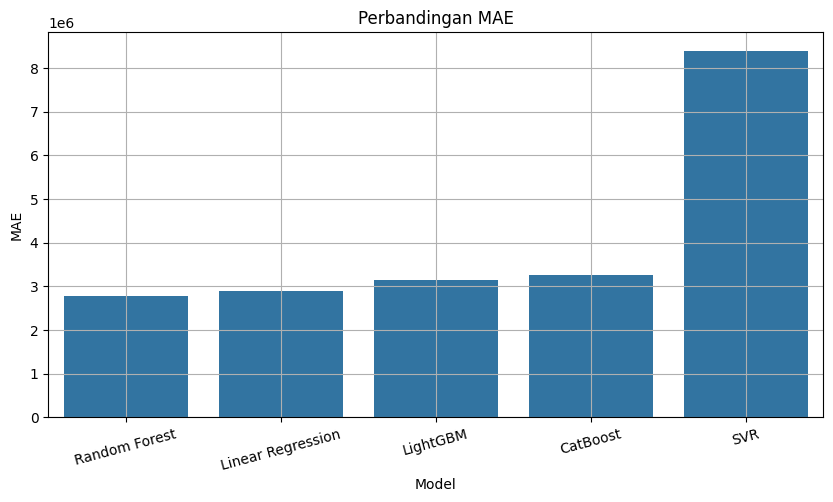

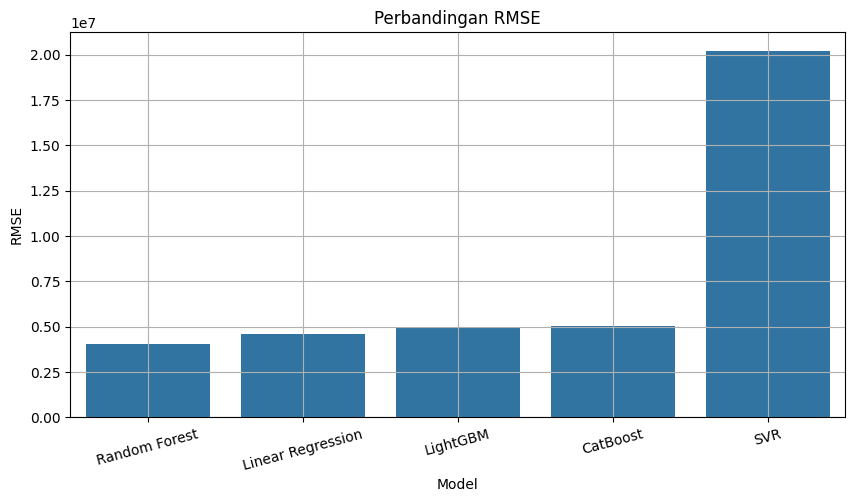

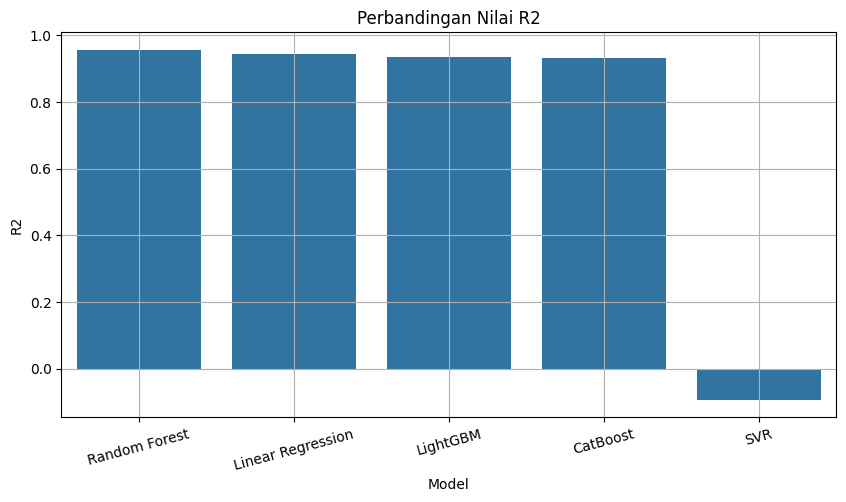

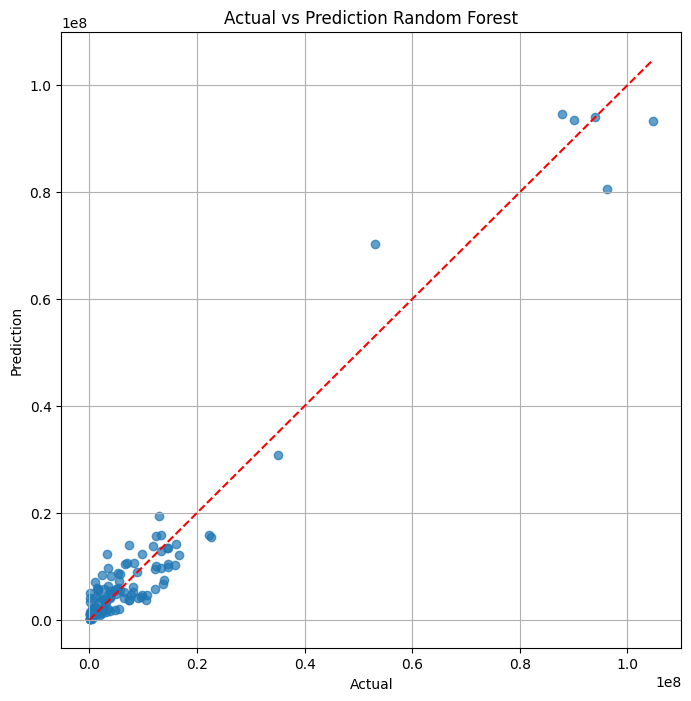

In [13]:
# PERBANDINGAN MAE
plt.figure(figsize=(10,5))

sns.barplot(
    x='Model',
    y='MAE',
    data=results_df
)

plt.title('Perbandingan MAE')
plt.xticks(rotation=15)
plt.grid(True)
plt.show()

# PERBANDINGAN RMSE
plt.figure(figsize=(10,5))

sns.barplot(
    x='Model',
    y='RMSE',
    data=results_df
)

plt.title('Perbandingan RMSE')
plt.xticks(rotation=15)
plt.grid(True)
plt.show()

# PERBANDINGAN R2
plt.figure(figsize=(10,5))

sns.barplot(
    x='Model',
    y='R2',
    data=results_df
)

plt.title('Perbandingan Nilai R2')
plt.xticks(rotation=15)
plt.grid(True)
plt.show()

# ACTUAL VS PREDICTION
plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.7
)

max_value = max(y_test.max(), y_pred_rf.max())

plt.plot(
    [0, max_value],
    [0, max_value],
    'r--'
)

plt.xlabel('Actual')
plt.ylabel('Prediction')

plt.title('Actual vs Prediction Random Forest')

plt.grid(True)

plt.show()




**12. FEATURE IMPORTANCE**

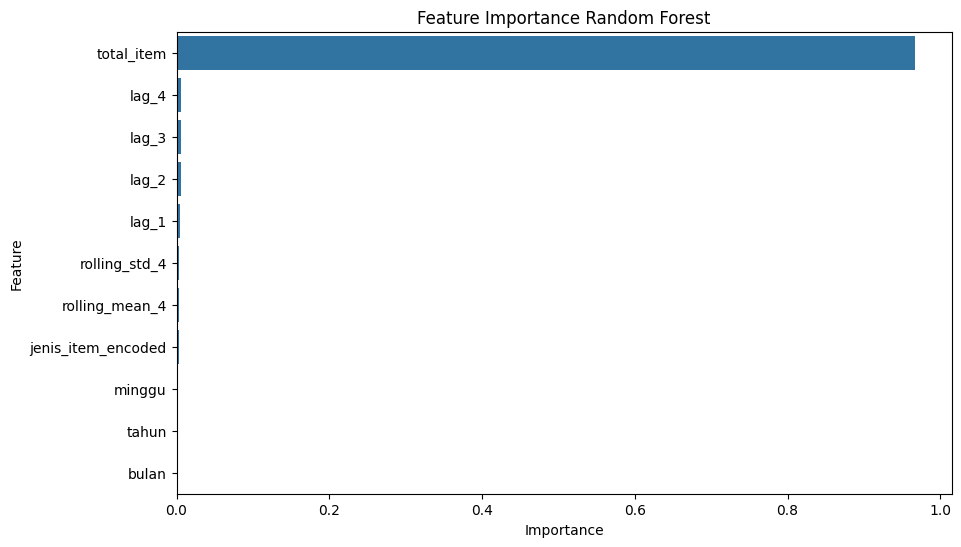



FEATURE IMPORTANCE
               Feature  Importance
4           total_item    0.966351
8                lag_4    0.005861
7                lag_3    0.005417
6                lag_2    0.005251
5                lag_1    0.004021
10       rolling_std_4    0.003155
9       rolling_mean_4    0.002972
3   jenis_item_encoded    0.002784
2               minggu    0.001759
0                tahun    0.001525
1                bulan    0.000904


In [14]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df
)

plt.title('Feature Importance Random Forest')
plt.show()

print("\n")
print("="*60)
print("FEATURE IMPORTANCE")
print("="*60)
print(importance_df)

**13. FORECAST MINGGU DEPAN**

In [15]:
future_data = weekly_sales.tail(10).copy()

future_data['minggu'] = future_data['minggu'] + 1

future_X = future_data[
    [
        'tahun',
        'bulan',
        'minggu',
        'jenis_item_encoded',
        'total_item',
        'lag_1',
        'lag_2',
        'lag_3',
        'lag_4',
        'rolling_mean_4',
        'rolling_std_4'
    ]
]

future_predictions = rf.predict(future_X)

future_result = pd.DataFrame({
    'Jenis_Item': future_data['jenis_item'].values,
    'Prediksi_Penjualan': future_predictions
})

print("\n")
print("="*60)
print("HASIL FORECAST MINGGU DEPAN")
print("="*60)
print(future_result)



HASIL FORECAST MINGGU DEPAN
      Jenis_Item  Prediksi_Penjualan
0  Novel Romansa        7.436118e+06
1  Novel Romansa        8.421150e+06
2  Novel Romansa        3.324923e+06
3  Novel Romansa        3.697537e+06
4  Novel Romansa        5.703209e+06
5  Novel Romansa        3.775998e+06
6  Novel Romansa        2.029237e+06
7  Novel Romansa        9.468528e+07
8  Novel Romansa        9.666182e+06
9  Novel Romansa        7.033446e+07


**14. VISUALISASI FORECAST**

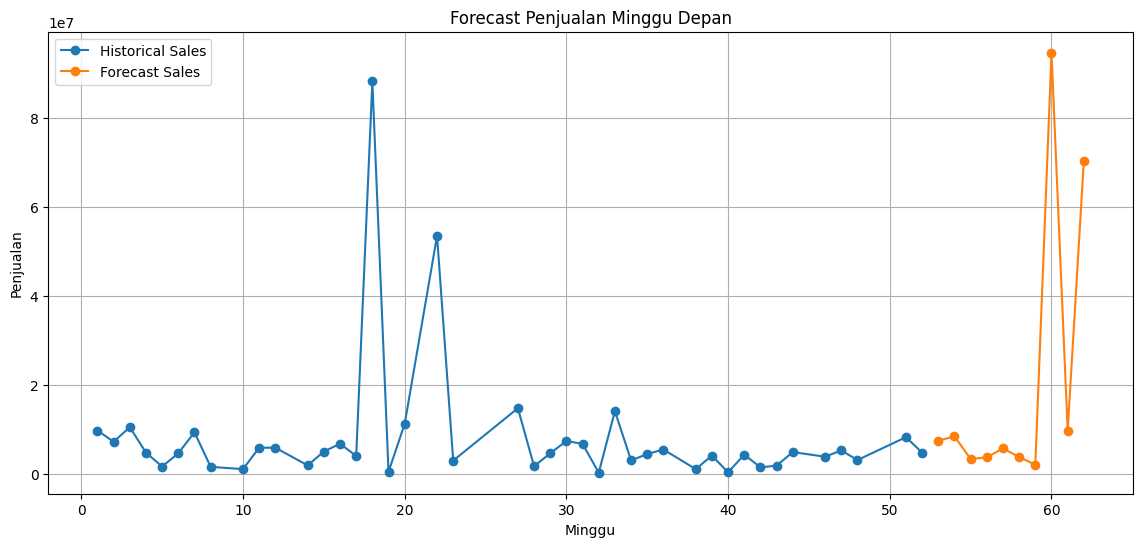

In [16]:
plt.figure(figsize=(14,6))

historical = weekly_sales.groupby(
    'minggu'
)['total_penjualan'].mean()

future_plot = pd.Series(
    future_predictions
)

historical.plot(
    label='Historical Sales',
    marker='o'
)

future_plot.index = range(
    historical.index.max()+1,
    historical.index.max()+1+len(future_plot)
)

future_plot.plot(
    label='Forecast Sales',
    marker='o'
)

plt.title('Forecast Penjualan Minggu Depan')
plt.xlabel('Minggu')
plt.ylabel('Penjualan')
plt.legend()
plt.grid(True)
plt.show()


**15. KESIMPULAN**

In [17]:
print(f"""
Model terbaik berdasarkan hasil evaluasi adalah:
{best_model_name}

Dengan nilai R2 sebesar:
{best_r2:.4f}

Model Random Forest menunjukkan performa terbaik
dalam memprediksi penjualan mingguan toko buku.

Penambahan fitur time series seperti lag feature
dan rolling statistics berhasil meningkatkan
akurasi model prediksi.

Pendekatan machine learning dapat digunakan
untuk membantu proses pengambilan keputusan
dalam manajemen stok dan estimasi penjualan.
""")



Model terbaik berdasarkan hasil evaluasi adalah:
Random Forest

Dengan nilai R2 sebesar:
0.9567

Model Random Forest menunjukkan performa terbaik
dalam memprediksi penjualan mingguan toko buku.

Penambahan fitur time series seperti lag feature
dan rolling statistics berhasil meningkatkan
akurasi model prediksi.

Pendekatan machine learning dapat digunakan
untuk membantu proses pengambilan keputusan
dalam manajemen stok dan estimasi penjualan.



# **DEPLOYMENT**

In [18]:
import joblib

model_objects = {
    "Linear Regression": lr,
    "Random Forest": rf,
    "LightGBM": lgbm,
    "CatBoost": cat,
    "SVR": svr
}

best_model = model_objects[best_model_name]

feature_columns = [
    'tahun', 'bulan', 'minggu', 'jenis_item_encoded', 'total_item',
    'lag_1', 'lag_2', 'lag_3', 'lag_4', 'rolling_mean_4', 'rolling_std_4'
]

joblib.dump(best_model, 'model_terbaik.pkl')
joblib.dump(le, 'label_encoder.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(feature_columns, 'feature_columns.pkl')

['feature_columns.pkl']